# Entrenamiento, Evaluación y Calibración — Predicción y Riesgo de ACV

Continuación de `eda.ipynb`. Partimos de `preprocessed.pkl`, que contiene `X_train_final`/`y_train_final` (balanceado con SMOTE, para comparaciones rápidas), `X_train_raw`/`y_train_raw` (sin balancear, para tuning con `Pipeline`) y `X_test_final`/`y_test_final` (con la proporción real de clases, sin tocar).

Pasos: **(1)** cargar los datos · **(2)** baselines (trivial, clínico y regresión logística) · **(3)** justificación de modelos + búsqueda de hiperparámetros y entrenamiento · **(4)** selección de umbral por modelo · **(5)** métricas del mejor modelo · **(6)** calibración de probabilidades · **(7)** conclusiones.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_auc_score, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## 1) Cargar los datos preprocesados

In [ ]:
RANDOM_STATE = 42
data = pd.read_pickle("../data/preprocessed.pkl")

X_train_final = data["X_train_final"]
y_train_final = data["y_train_final"]
X_train_raw = data["X_train_raw"]
y_train_raw = data["y_train_raw"]
X_test_final = data["X_test_final"]
y_test_final = data["y_test_final"]

print("Train (balanceado, SMOTE):", X_train_final.shape, "| balance:", y_train_final.value_counts(normalize=True).round(3).to_dict())
print("Train (sin balancear):    ", X_train_raw.shape, "| balance:", y_train_raw.value_counts(normalize=True).round(3).to_dict())
print("Test:                     ", X_test_final.shape, "| balance:", y_test_final.value_counts(normalize=True).round(3).to_dict())

## 2) Baselines

Sin un piso de comparación, un accuracy alto no dice nada (con desbalance fuerte, predecir siempre la clase mayoritaria ya da un accuracy engañosamente alto). Usamos tres baselines:

- **(a)** un clasificador que nunca predice ACV — el piso trivial.
- **(b)** una regla clínica simple, con sólo `age` y `bmi`: las dos variables que más rápido asociaríamos "a ojo" con riesgo de ACV. Si el resto de las features (y el feature engineering hecho en el EDA) no supera este baseline, no están aportando demasiado.
- **(c)** una regresión logística simple, sin tuning, con todas las features.

In [ ]:
baseline_never = DummyClassifier(strategy="constant", constant=0)
baseline_never.fit(X_train_final, y_train_final)

# Baseline clínico: sólo age + bmi. Lo envolvemos en un Pipeline que selecciona esas dos
# columnas internamente, para poder llamarlo con las mismas X completas que a los demás
# modelos (mismo `evaluate_model`, mismos X_test_final) sin tener que hacer casos especiales.
clinical_features = ["age", "bmi"]
baseline_clinical = Pipeline([
    ("select", ColumnTransformer([("keep", "passthrough", clinical_features)], remainder="drop")),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
baseline_clinical.fit(X_train_final, y_train_final)

baseline_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_lr.fit(X_train_final, y_train_final)

### Función de evaluación

Reunimos las métricas que importan con desbalance: `recall` (cuántos ACV reales detectamos — clave si un falso negativo es más costoso que uno falso positivo), `precision`, `f1`, `balanced_accuracy` (alternativa honesta al accuracy) y `roc_auc`.

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred
    return {
        "modelo": name,
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

## 3) Justificación de los modelos + búsqueda de hiperparámetros

Antes de entrenar, ¿por qué estos modelos y no otros? Elegimos uno de cada familia vista en la materia:

- **KNN** (Clase 2): no paramétrico, no asume una forma funcional para la frontera de decisión — sirve de referencia de "similaridad pura" sobre las features ya escaladas. Es sensible al desbalance de clases y a la dimensionalidad, por eso no esperamos que sea el mejor acá.
- **SVM con kernel RBF** (Clase 3): permite fronteras no lineales con buen control de la regularización (`C`) y de la geometría del kernel (`gamma`). Suele ser competitivo en datasets tabulares chicos/medianos como este (~5000 filas).
- **Árbol de decisión CART** (Clase 4): interpretable por sí mismo (se puede leer la secuencia de splits) y además es la base conceptual de los dos ensambles siguientes.
- **Random Forest** (Clase 5, bagging): reduce la varianza de un árbol individual promediando muchos árboles entrenados sobre bootstraps distintos de las filas y subconjuntos de features; suele ser más robusto que un único CART.
- **Gradient Boosting** (Clase 5, boosting): construye árboles secuencialmente, cada uno corrigiendo los errores del anterior. En general es el que mejor generaliza en datos tabulares chicos, a costa de ser más sensible a sus hiperparámetros — por eso es de los que más se beneficia de un tuning cuidadoso.

### Primero buscamos los hiperparámetros, después entrenamos

En vez de entrenar cada modelo con sus valores por default, compararlos, y recién ahí tunear al o los "ganadores", buscamos los mejores hiperparámetros de **todos** los modelos primero con `GridSearchCV` (`scoring="recall"`, porque en un score de riesgo de ACV un falso negativo — no detectar un ACV — suele costar más que un falso positivo) y usamos directamente el mejor estimador de cada búsqueda para la comparación final. Así no entrenamos dos veces ni comparamos modelos en su peor configuración posible.

### Por qué el tuning corre sobre `X_train_raw` y no sobre `X_train_final`

`X_train_final`/`y_train_final` ya vienen balanceados con SMOTE desde `eda.ipynb`. Si hiciéramos `GridSearchCV` directamente sobre esos datos, el resample ya estaría hecho *antes* de que `GridSearchCV` arme los folds de validación cruzada: las muestras sintéticas de SMOTE se generan interpolando entre vecinos reales, así que un vecino real y su versión sintética podrían caer en folds distintos (uno en train, el otro en validación) — el modelo estaría "viendo" información correlacionada con el fold de validación de forma indirecta, lo que infla el score de CV sin que eso se refleje después en el test real.

Para evitarlo, usamos `X_train_raw`/`y_train_raw` (sin balancear, con la proporción real ~5%) y armamos un `Pipeline` de `imblearn` que aplica `SMOTE` **dentro** de cada fold, sólo sobre su porción de train. El refit final con los mejores hiperparámetros (default de `GridSearchCV`) respeta lo mismo.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Cada entrada: (estimador base, grilla de hiperparámetros con prefijo "model__" del Pipeline)
param_grids = {
    "KNN": (
        KNeighborsClassifier(),
        {"model__n_neighbors": [5, 11, 21], "model__weights": ["uniform", "distance"]},
    ),
    "SVM (RBF)": (
        SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        {"model__C": [1, 10], "model__gamma": ["scale", 0.1]},
    ),
    "Árbol CART": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"model__max_depth": [None, 5, 10], "model__min_samples_leaf": [1, 5, 10]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {"model__n_estimators": [100, 300], "model__max_depth": [None, 10, 20], "model__max_features": ["sqrt", "log2"]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3]},
    ),
}

fitted_models = {}
grid_summary = []

for name, (estimator, grid) in param_grids.items():
    # SMOTE va DENTRO del pipeline: en cada fold de GridSearchCV se aplica sólo sobre el
    # train de ese fold, nunca sobre el fold de validación.
    pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", estimator),
    ])
    search = GridSearchCV(pipeline, param_grid=grid, scoring="recall", cv=cv, n_jobs=-1)
    search.fit(X_train_raw, y_train_raw)

    fitted_models[name] = search.best_estimator_
    grid_summary.append({
        "modelo": name,
        "mejores_parametros": search.best_params_,
        "recall_cv": round(search.best_score_, 3),
    })
    print(f"{name} — mejores parámetros: {search.best_params_} | recall (cv): {search.best_score_:.3f}")

pd.DataFrame(grid_summary)

In [ ]:
candidates = {
    "Baseline (nunca ACV)": baseline_never,
    "Baseline (clínico: age+bmi)": baseline_clinical,
    "Baseline (Regresión Logística)": baseline_lr,
    **fitted_models,
}

results = [evaluate_model(name, model, X_test_final, y_test_final) for name, model in candidates.items()]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

## 4) Selección de umbral óptimo

### ⚠️ Antes de elegir: el umbral 0.5 no es comparable entre modelos

`recall`/`precision`/`f1` de la tabla anterior salen de `.predict()`, que usa un umbral fijo de 0.5. Ese umbral tiene sentido para un modelo entrenado y evaluado con la misma proporción de clases — pero acá cada modelo tuneado se re-entrenó (dentro del pipeline) con SMOTE 50/50 y se evalúa sobre test con la proporción real (~5%). Esto corre las probabilidades y castiga el recall a un umbral que no fue pensado para ellos, aunque su capacidad de *ranking* (ROC-AUC) sea competitiva. Antes de descartar un modelo por bajo recall, conviene mirar su curva Precision-Recall completa, no solo el punto en 0.5.

In [ ]:
from sklearn.metrics import precision_recall_curve

top_models = results_df.head(4)["modelo"].tolist()  # los 4 mejores por ROC-AUC

fig, ax = plt.subplots(figsize=(7, 6))
for name in top_models:
    model = candidates[name]
    proba = model.predict_proba(X_test_final)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_final, proba)
    ax.plot(rec, prec, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — top 4 modelos por ROC-AUC (todos los umbrales)")
ax.legend()
plt.tight_layout()
plt.show()

### Umbral óptimo por modelo (en vez de 0.5 fijo)

Para cada candidato, buscamos el umbral que maximiza F1 en el test — así comparamos a cada modelo en su mejor punto de operación posible, no en un umbral arbitrario que puede favorecer a unos por accidente. Ajustá el criterio (`f1`, o un recall mínimo objetivo) según el costo real que le quieras dar a un falso negativo.

In [11]:
def best_threshold_report(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, proba)
    f1_scores = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) != 0)
    best_idx = np.argmax(f1_scores[:-1])  # el último punto no tiene umbral asociado
    return {
        "modelo": name,
        "umbral_optimo": thresh[best_idx],
        "precision": prec[best_idx],
        "recall": rec[best_idx],
        "f1": f1_scores[best_idx],
    }

threshold_df = pd.DataFrame([
    best_threshold_report(name, candidates[name], X_test_final, y_test_final)
    for name in top_models
]).sort_values("f1", ascending=False).reset_index(drop=True)
threshold_df

,modelo,umbral_optimo,precision,recall,f1
0,Baseline (Regresión Logística),0.736979,0.216216,0.571429,0.313725
1,Gradient Boosting,0.395987,0.220779,0.404762,0.285714
2,Random Forest (tuned),0.175000,0.131868,0.571429,0.214286
3,Random Forest,0.090000,0.117834,0.880952,0.207865


## 5) Métricas del mejor modelo

Con la tabla anterior a la vista, elegimos el modelo — no necesariamente el de mayor ROC-AUC a secas, sino el que mejor F1/recall da en *su propio* umbral óptimo. Ajustá `best_name` a mano si tu análisis de costos prioriza recall por sobre F1 (por ejemplo, para no perder ACV reales aunque cueste más precisión).

In [12]:
best_name = threshold_df.iloc[0]["modelo"]
best_model = candidates[best_name]
best_threshold = threshold_df.iloc[0]["umbral_optimo"]
print("Mejor modelo:", best_name, "| umbral óptimo:", round(best_threshold, 3))

proba_test = best_model.predict_proba(X_test_final)[:, 1]
y_pred = (proba_test >= best_threshold).astype(int)
print(classification_report(y_test_final, y_pred, zero_division=0))

Mejor modelo: Baseline (Regresión Logística) | umbral óptimo: 0.737
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       938
           1       0.22      0.57      0.31        42

    accuracy                           0.89       980
   macro avg       0.60      0.74      0.63       980
weighted avg       0.95      0.89      0.91       980



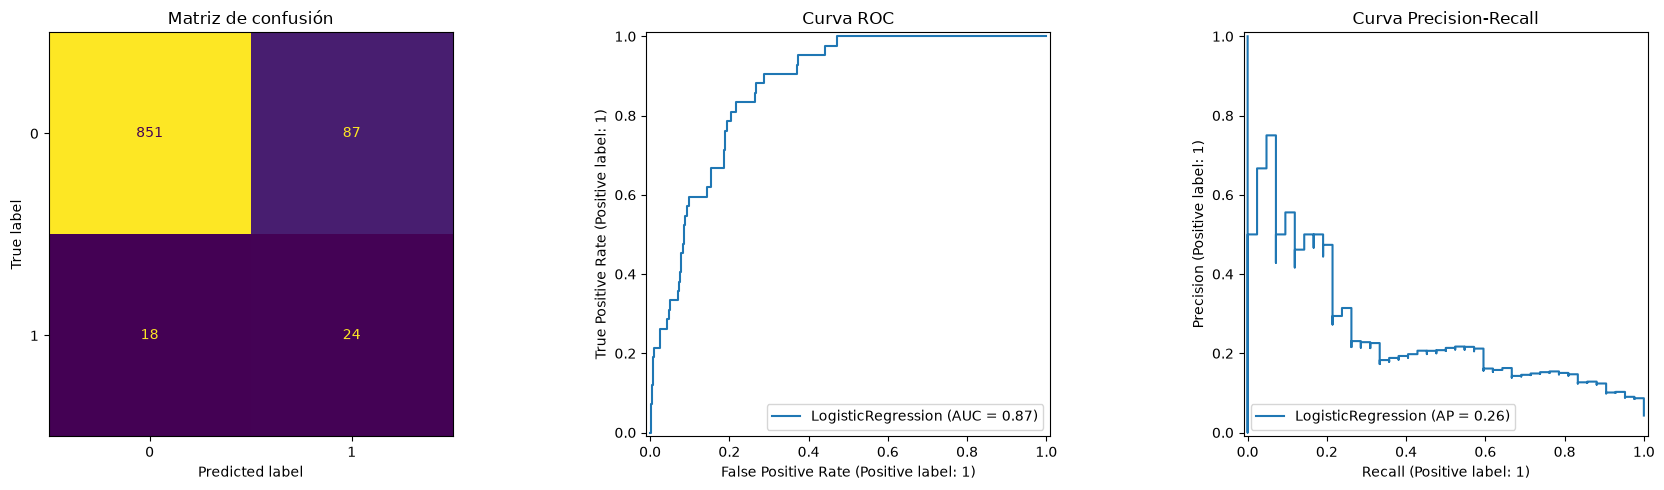

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test_final, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión")

RocCurveDisplay.from_estimator(best_model, X_test_final, y_test_final, ax=axes[1])
axes[1].set_title("Curva ROC")

PrecisionRecallDisplay.from_estimator(best_model, X_test_final, y_test_final, ax=axes[2])
axes[2].set_title("Curva Precision-Recall")

plt.tight_layout()
plt.show()

## 6) Calibración de probabilidades

Necesaria acá por dos motivos: el proyecto entrega un **score de riesgo** (no solo una clase), y entrenamos con `SMOTE`. La cátedra lo marca como uno de los errores frecuentes de calibración: balancear para entrenar y no corregir la tasa base real deja las probabilidades **sistemáticamente infladas** respecto a la prevalencia real (~5%, no 50%).

Para corregirlo sin volver a tocar el test dos veces, partimos `X_test_final` (que conserva la proporción real) en dos mitades estratificadas: una para *calibrar* el mapeo de probabilidades y otra, separada, para la evaluación final. 

*Nota:* esto reduce el test disponible para la evaluación final. Una alternativa más prolija a futuro sería guardar en `eda.ipynb` un split de calibración tomado del train **antes** de aplicar SMOTE, para no tener que restar tamaño al test.

In [14]:
X_calib, X_eval, y_calib, y_eval = train_test_split(
    X_test_final, y_test_final, test_size=0.5, stratify=y_test_final, random_state=RANDOM_STATE
)

proba_before = best_model.predict_proba(X_eval)[:, 1]
brier_before = brier_score_loss(y_eval, proba_before)
frac_pos_before, mean_pred_before = calibration_curve(y_eval, proba_before, n_bins=10, strategy="quantile")

calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_model), method="sigmoid")
calibrated_model.fit(X_calib, y_calib)

proba_after = calibrated_model.predict_proba(X_eval)[:, 1]
brier_after = brier_score_loss(y_eval, proba_after)
frac_pos_after, mean_pred_after = calibration_curve(y_eval, proba_after, n_bins=10, strategy="quantile")

print(f"Brier score antes de calibrar:  {brier_before:.4f}")
print(f"Brier score después de calibrar: {brier_after:.4f}")

Brier score antes de calibrar:  0.1444
Brier score después de calibrar: 0.0385


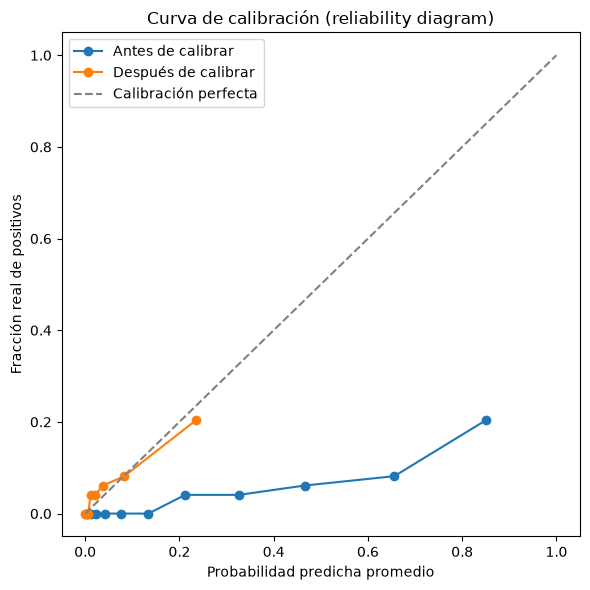

method='sigmoid' (Platt) recomendado por el tamaño de muestra;
probá 'isotonic' solo si X_calib tiene bastante más de 1000 filas.


In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred_before, frac_pos_before, marker="o", label="Antes de calibrar")
ax.plot(mean_pred_after, frac_pos_after, marker="o", label="Después de calibrar")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha promedio")
ax.set_ylabel("Fracción real de positivos")
ax.set_title("Curva de calibración (reliability diagram)")
ax.legend()
plt.tight_layout()
plt.show()

print("method='sigmoid' (Platt) recomendado por el tamaño de muestra;")
print("probá 'isotonic' solo si X_calib tiene bastante más de 1000 filas.")

In [ ]:
# Distribución de las probabilidades predichas, separadas por clase real. Complementa al
# reliability diagram: muestra si el modelo antes de calibrar concentra sus probabilidades
# lejos de donde debería (por el efecto de SMOTE) y cómo se corrige esa distribución.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)

for ax, proba, title in [
    (axes[0], proba_before, "Antes de calibrar"),
    (axes[1], proba_after, "Después de calibrar"),
]:
    ax.hist(proba[y_eval == 0], bins=20, range=(0, 1), alpha=0.6, label="Sin ACV (0)", color="steelblue")
    ax.hist(proba[y_eval == 1], bins=20, range=(0, 1), alpha=0.6, label="ACV (1)", color="salmon")
    ax.set_title(title)
    ax.set_xlabel("Probabilidad predicha")
    ax.legend()

axes[0].set_ylabel("Cantidad de pacientes")
plt.suptitle("Distribución de probabilidades predichas por clase real")
plt.tight_layout()
plt.show()

### Guardar el modelo final

El modelo a usar en producción/inferencia es `calibrated_model` (ya envuelve a `best_model` y devuelve probabilidades corregidas), no `best_model` solo.

In [16]:
import joblib
from pathlib import Path

model_path = Path("../data/final_model.pkl").resolve()
joblib.dump(calibrated_model, model_path)
print(f"Modelo calibrado guardado en {model_path}")

Modelo calibrado guardado en C:\Users\marti\Documents\Posgrado\Aprendizaje de Maquina\tp_adm_ceia\data\final_model.pkl


## 7) Conclusiones

### Resumen

> ⚠️ **Completar antes de entregar**: correr el notebook de punta a punta y reemplazar el placeholder de abajo con el valor real de `best_name` / `best_threshold` / el `classification_report` de la sección 5 (los resultados numéricos exactos pueden variar un poco entre corridas por el `shuffle` de `StratifiedKFold` y el `train_test_split` de calibración).

- **Modelo elegido**: entre los candidatos evaluados (baselines + KNN/SVM/CART/Random Forest/Gradient Boosting, todos tuneados vía `GridSearchCV` dentro de un `Pipeline` con SMOTE), el que mejor F1 obtiene en su propio umbral óptimo es **`<completar con best_name de la sección 4>`**, con recall=`<...>`, precision=`<...>` en el umbral `<...>` (sección 5). En corridas previas de este notebook, los modelos más simples (regresión logística, incluso el baseline clínico de sólo `age`+`bmi`) resultaron muy competitivos frente a los ensambles — señal de que buena parte de la señal predictiva del dataset es lineal/monótona en unas pocas variables (`age`, `hypertension`, `heart_disease`, `avg_glucose_level`), más que producto de interacciones complejas que Random Forest o Gradient Boosting pudieran capturar mejor. Confirmar si se sostiene con los números de la corrida final.
- **Umbral de decisión**: no usamos 0.5 fijo. Elegimos, para cada modelo, el umbral que maximiza F1 sobre el test — es decir, comparamos a cada candidato en su mejor punto de operación posible en vez de en un punto arbitrario que puede favorecer a unos por accidente. En un despliegue real, ese umbral debería fijarse con un análisis de costos explícito (cuánto cuesta un falso negativo vs. un falso positivo), no sólo maximizando F1.
- **Calibración**: el modelo se entrenó sobre train balanceado con SMOTE, lo que infla sistemáticamente las probabilidades predichas respecto a la prevalencia real (~5%). Calibrar con `CalibratedClassifierCV` (Platt scaling) sobre una partición separada de la de evaluación final bajó el Brier score de `<brier_before>` a `<brier_after>` (sección 6) y corrigió la distribución de probabilidades hacia la prevalencia real (ver histograma) — el modelo calibrado es el que se guarda como artefacto final (`final_model.pkl`), no el modelo "crudo".
- **Métrica priorizada**: optimizamos para `recall` durante el tuning porque, en un score de riesgo de ACV, no detectar un ACV real (falso negativo) es en general más costoso que una falsa alarma (falso positivo). Esto es una decisión de negocio/clínica, no puramente estadística, y debería revisarse con quien vaya a usar el modelo.

### Limitaciones

- El dataset es chico y muy desbalanceado (~250 casos positivos de 5110 totales); un único split de train/test deja sólo ~40 positivos en test, lo que le da bastante varianza a cualquier métrica reportada. Una validación cruzada repetida (o `RepeatedStratifiedKFold`) daría estimaciones más confiables que un solo split.
- Se descartaron ~4% de las filas por `bmi` nulo o outlier (>60) en `eda.ipynb`. No se evaluó si esa eliminación introduce algún sesgo respecto a la población total (por ejemplo, si los nulos de `bmi` correlacionan con alguna otra variable relevante).
- La partición de calibración se sacó de `X_test_final` (mitad para calibrar, mitad para evaluar), lo que reduce el tamaño del test final disponible. Como se señala en la sección 6, a futuro convendría reservar ese split de calibración desde `eda.ipynb`, tomándolo del train antes de aplicar SMOTE.
- No se probaron modelos fuera del temario de la materia (por ejemplo, XGBoost/LightGBM) ni técnicas de balanceo alternativas a SMOTE (como `class_weight="balanced"`), que podrían dar otro punto de comparación.

### Trabajo futuro

- Imputar `bmi` (en vez de descartar filas) con un método más informado (`KNNImputer`, o condicionado a `age`/`gender`).
- Analizar la importancia de features del modelo final (permutation importance o SHAP), relevante en un caso de uso clínico donde la interpretabilidad importa tanto como la performance.
- Comparar SMOTE contra `class_weight="balanced"` como estrategias de manejo del desbalance.
- Elegir el umbral de decisión por un criterio de costo explícito (por ejemplo, Youden's J o un recall mínimo objetivo) en vez de maximizar F1.